## 각 데이터셋별로 train, validation, test 데이터셋 분리 (user_id 기준)

In [49]:
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

def tr_val_test_split(df):
    # 1개 이하만 존재하는 클래스는 train set에 포함
    class_counts = df['age_class'].value_counts()
    valid_classes = class_counts[class_counts >= 2].index
    stratify_df = df[df['age_class'].isin(valid_classes)]

    rare_df = df[~df['age_class'].isin(valid_classes)]

    train_df, tmp_df = train_test_split(stratify_df, test_size=0.2, random_state=42, stratify=stratify_df['age_class'])
    train_df = pd.concat([train_df, rare_df], ignore_index=True)

    try:
        val_df, test_df = train_test_split(tmp_df, test_size=0.5, stratify=tmp_df['age_class'], random_state=42)
    except ValueError as e:
        tmp_class_counts = tmp_df['age_class'].value_counts()
        tmp_valid_classes = tmp_class_counts[tmp_class_counts >= 2].index
        tmp_stratify_df = tmp_df[tmp_df['age_class'].isin(tmp_valid_classes)]

        tmp_rare_df = tmp_df[~tmp_df['age_class'].isin(tmp_valid_classes)]

        val_df, test_df = train_test_split(tmp_stratify_df, test_size=0.2, random_state=42, stratify=tmp_stratify_df['age_class'])
        val_df = pd.concat([val_df, tmp_rare_df], ignore_index=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    counts = [train_df['age_class'].value_counts().sort_index(), val_df.value_counts('age_class').sort_index(), test_df.value_counts('age_class').sort_index()]
    
    for i, ax in enumerate(axes):
        counts[i].plot(kind='bar', ax=ax)
        ax.set_title(['Train', 'Validation', 'Test'][i])
        ax.set_xlabel('age_class')
        ax.set_ylabel('count')
    plt.tight_layout()
    
    plt.show()

    return train_df, val_df, test_df

### 028_data

In [74]:
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/v0.2_data/age/028_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'age_label.json'), orient='records', dtype={'user_id':str, })
user_split = origin_df.loc[:, ['user_id', 'age_class']].drop_duplicates(ignore_index=True)
user_split

,user_id,age_class
0,0001,4
1,0002,4
2,0003,1
3,0004,3
4,0006,4
...,...,...
960,1096,1
961,1097,1
962,1098,1
963,1099,1


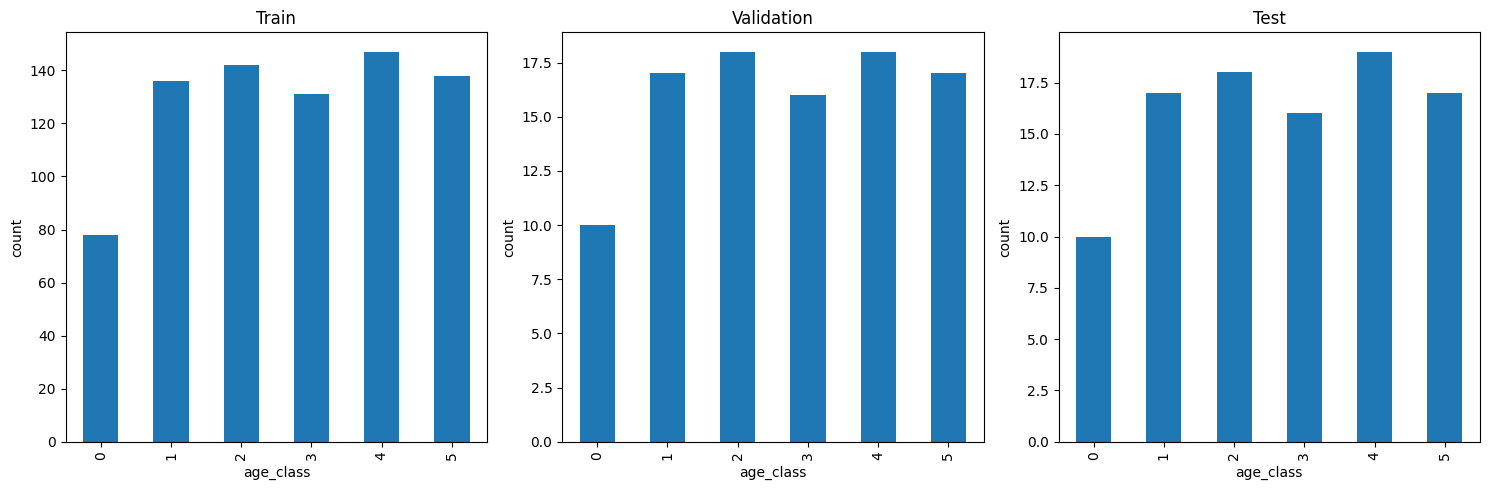

In [75]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [76]:
len(train_df)

772

In [77]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])

In [78]:
split_train.drop(columns=['age_class_x'], inplace=True)
split_train.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_val.drop(columns=['age_class_x'], inplace=True)
split_val.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_test.drop(columns=['age_class_x'], inplace=True)
split_test.rename(columns={'age_class_y': 'age_class'}, inplace=True)

In [79]:
# user_id로 교집합을 구하여 중복된 user_id의 수를 확인

len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [26]:
with open(os.path.join(label_dir, 'age_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 030_data

In [27]:
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/v0.2_data/age/030_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'age_label.json'), orient='records', dtype={'user_id':str, })
user_split = origin_df.loc[:, ['user_id', 'age_class']].drop_duplicates(ignore_index=True)
user_split

,user_id,age_class
0,0003,0
1,0004,0
2,0005,0
3,0006,0
4,0007,0
...,...,...
1593,1976,5
1594,1977,6
1595,1978,5
1596,1979,6


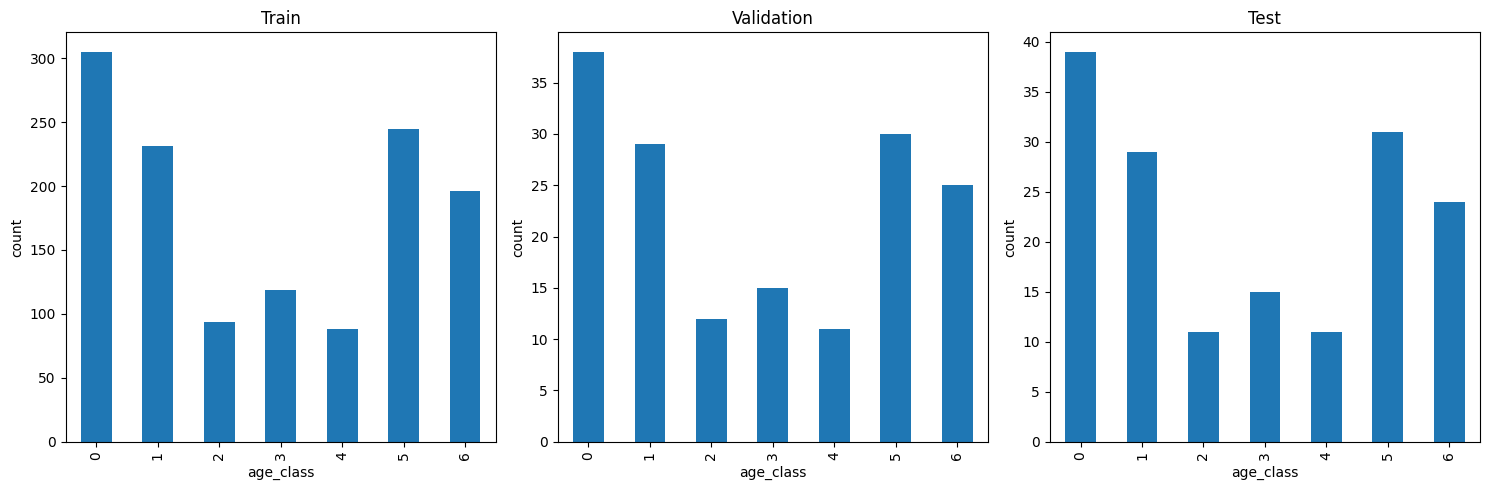

In [28]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [29]:
# train, val, test의 개수 합이 origin과 같으면 한 사람이 여러장 찍지 않았음
len(origin_df), len(train_df), len(val_df), len(test_df)

(1598, 1278, 160, 160)

In [30]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])

In [31]:
split_train.drop(columns=['age_class_x'], inplace=True)
split_train.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_val.drop(columns=['age_class_x'], inplace=True)
split_val.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_test.drop(columns=['age_class_x'], inplace=True)
split_test.rename(columns={'age_class_y': 'age_class'}, inplace=True)

In [32]:
# user_id로 교집합을 구하여 중복된 user_id의 수를 확인

len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [33]:
with open(os.path.join(label_dir, 'age_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 034_data

In [34]:
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/v0.2_data/age/034_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'age_label.json'), orient='records', dtype={'user_id':str, })
user_split = origin_df.loc[:, ['user_id', 'age_class']].drop_duplicates(ignore_index=True)
user_split

,user_id,age_class
0,0000,1
1,0001,1
2,0002,2
3,0003,2
4,0004,3
...,...,...
2681,2695,1
2682,2696,6
2683,2697,1
2684,2698,1


In [35]:
user_split['age_class'].value_counts().sort_index()

age_class
0      2
1    741
2    416
3    465
4    514
5    401
6    147
Name: count, dtype: int64

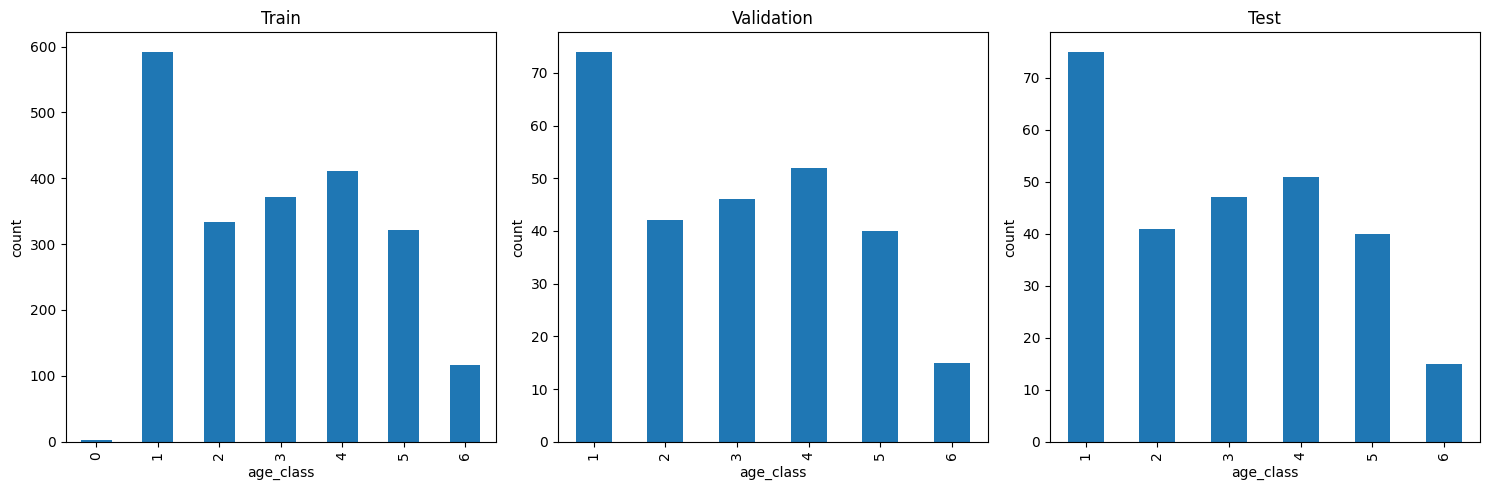

In [36]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [37]:
# train, val, test의 개수 합이 origin과 같으면 한 사람이 여러장 찍지 않았음
len(origin_df), len(train_df), len(val_df), len(test_df)

(5372, 2148, 269, 269)

In [38]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])

split_train.drop(columns=['age_class_x'], inplace=True)
split_train.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_val.drop(columns=['age_class_x'], inplace=True)
split_val.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_test.drop(columns=['age_class_x'], inplace=True)
split_test.rename(columns={'age_class_y': 'age_class'}, inplace=True)

# user_id로 교집합을 구하여 중복된 user_id의 수를 확인
len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [39]:
with open(os.path.join(label_dir, 'age_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 045_data

In [40]:
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/v0.2_data/age/045_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'age_label.json'), orient='records', dtype={'user_id':str, })
user_split = origin_df.loc[:, ['user_id', 'age_class']].drop_duplicates(ignore_index=True)
user_split

,user_id,age_class
0,F0001_IND_D,0
1,F0001_IND_GM,6
2,F0001_IND_M,3
3,F0002_IND_S,0
4,F0003_IND_D,0
...,...,...
787,F0898_IND_F,4
788,F0899_IND_M,3
789,F0900_IND_D,2
790,F0900_IND_F,4


In [41]:
user_split['age_class'].value_counts().sort_index()

age_class
0    263
1     66
2     38
3    199
4    113
5     48
6     65
Name: count, dtype: int64

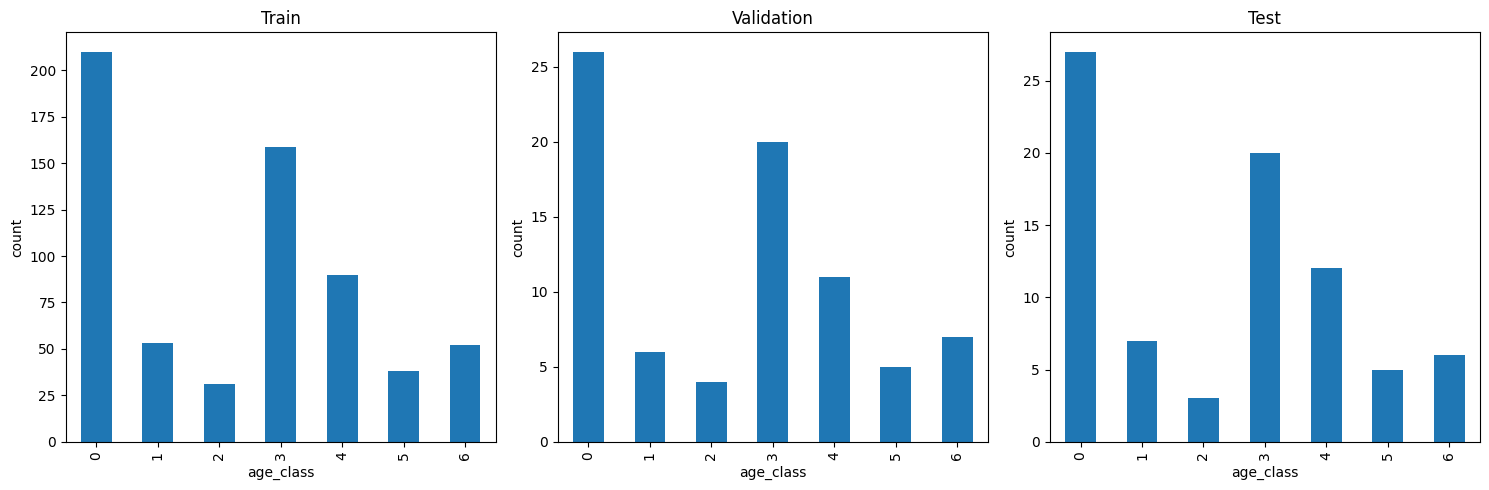

In [42]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [43]:
# train, val, test의 개수 합이 origin과 같으면 한 사람이 여러장 찍지 않았음
len(origin_df), len(train_df), len(val_df), len(test_df)

(3288, 633, 79, 80)

In [44]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])

split_train.drop(columns=['age_class_x'], inplace=True)
split_train.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_val.drop(columns=['age_class_x'], inplace=True)
split_val.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_test.drop(columns=['age_class_x'], inplace=True)
split_test.rename(columns={'age_class_y': 'age_class'}, inplace=True)

# user_id로 교집합을 구하여 중복된 user_id의 수를 확인
len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [45]:
with open(os.path.join(label_dir, 'age_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 092_data

In [10]:
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/datasets/v0.2_data/age/092_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'age_label.json'), orient='records', dtype={'user_id':str, })
user_split = origin_df.loc[:, ['user_id', 'age_class']].drop_duplicates(ignore_index=True)
user_split

,user_id,age_class
0,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,1
1,007f299267a9d6a145f627e9993aeae4e8323652785a2f...,2
2,01a6c69e76d729863380b8391d780e53070cf8629ad9ff...,2
3,020ebc10d4c4758048577c36ffa034c3759efd81ce478c...,2
4,028b639b49c5611a2c83ac7f8ac58e36c08c850c427e2a...,1
...,...,...
1075,fef632c79b7c11c46e87df1be8319d76e4b75da03f179a...,1
1076,ff0d2fd5e55c4b4054ec0e192930f747177654fffbc8b8...,1
1077,ff33e40411c2567947a3725f1401ea64a8d2bf9ed85529...,1
1078,ffc31d193435ff87f522e2c47de67ee0fd87892903367e...,2


In [11]:
user_split['age_class'].value_counts().sort_index()

age_class
0     16
1    586
2    323
3    116
4     36
5      3
Name: count, dtype: int64

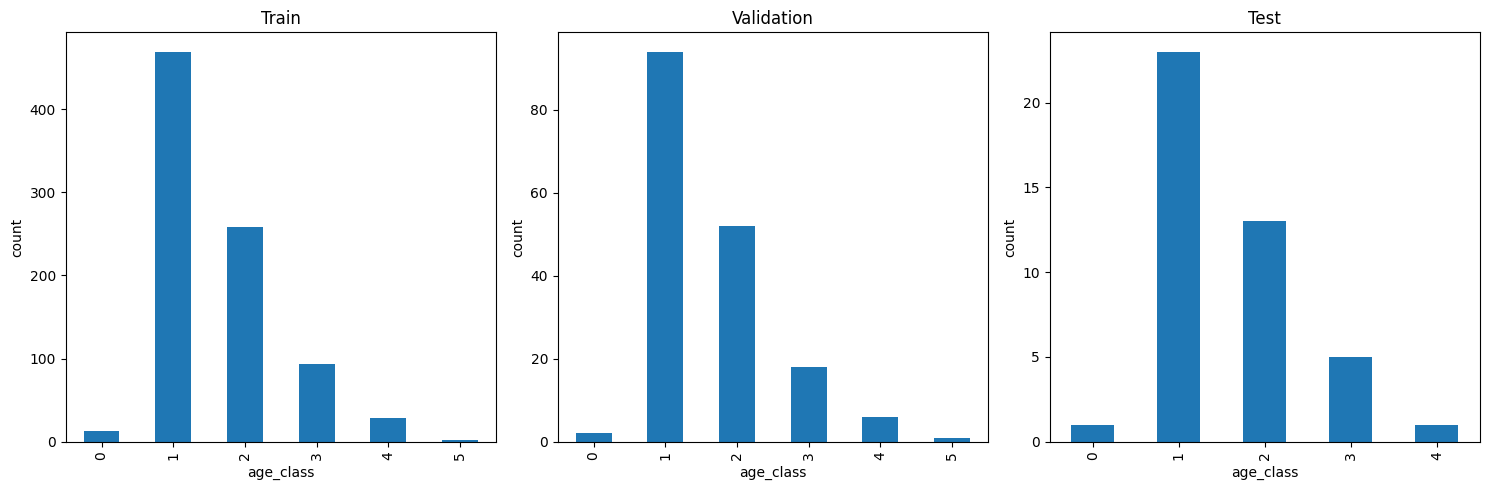

In [12]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [13]:
# train, val, test의 개수 합이 origin과 같으면 한 사람이 여러장 찍지 않았음
len(origin_df), len(train_df), len(val_df), len(test_df)

(66572, 864, 173, 43)

In [14]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])

split_train.drop(columns=['age_class_x'], inplace=True)
split_train.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_val.drop(columns=['age_class_x'], inplace=True)
split_val.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_test.drop(columns=['age_class_x'], inplace=True)
split_test.rename(columns={'age_class_y': 'age_class'}, inplace=True)

# user_id로 교집합을 구하여 중복된 user_id의 수를 확인
len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [15]:
with open(os.path.join(label_dir, 'age_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 117_data

In [61]:
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/v0.2_data/age/117_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'age_label.json'), orient='records', dtype={'user_id':str, })
user_split = origin_df.loc[:, ['user_id', 'age_class']].drop_duplicates(ignore_index=True)
user_split

,user_id,age_class
0,0031,1
1,0032,2
2,0035,4
3,0036,1
4,0037,3
...,...,...
2482,4216,3
2483,4217,3
2484,4218,1
2485,4219,1


In [62]:
user_split['age_class'].value_counts().sort_index()

age_class
0      7
1    664
2    614
3    584
4    364
5    190
6     64
Name: count, dtype: int64

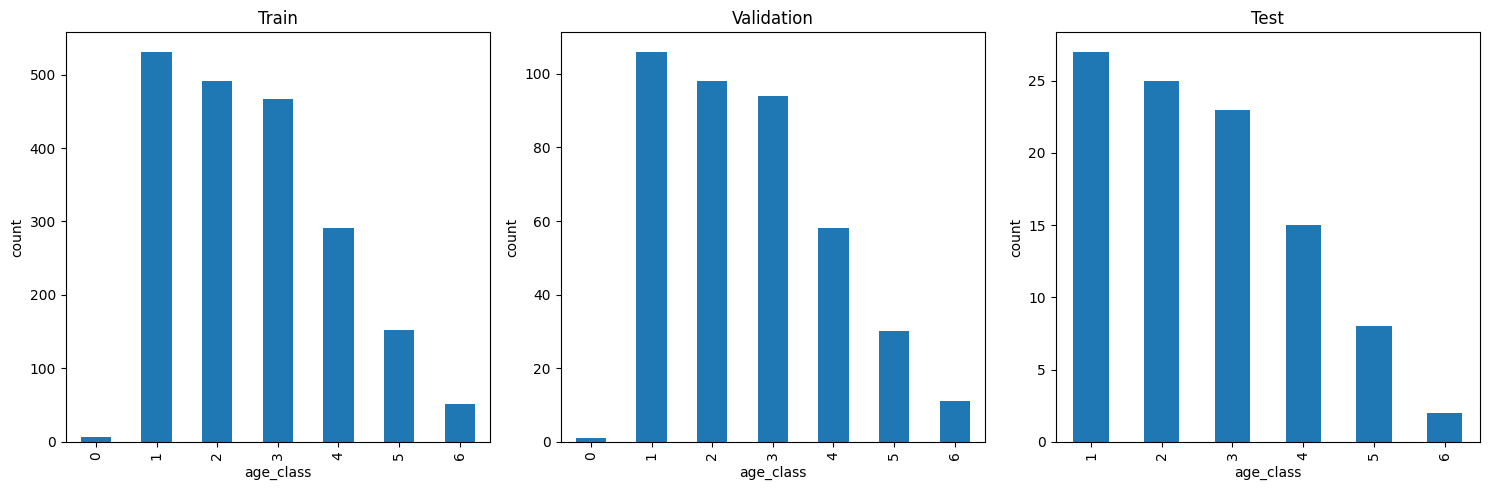

In [63]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [64]:
# train, val, test의 개수 합이 origin과 같으면 한 사람이 여러장 찍지 않았음
len(origin_df), len(train_df), len(val_df), len(test_df)

(15784, 1989, 398, 100)

In [65]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])

split_train.drop(columns=['age_class_x'], inplace=True)
split_train.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_val.drop(columns=['age_class_x'], inplace=True)
split_val.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_test.drop(columns=['age_class_x'], inplace=True)
split_test.rename(columns={'age_class_y': 'age_class'}, inplace=True)

# user_id로 교집합을 구하여 중복된 user_id의 수를 확인
len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [66]:
with open(os.path.join(label_dir, 'age_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 118_data

한 사람의 여러 연령대가 존재해서 문제 발생 -> user_id로만 분리하기. age_class는 적은쪽에 넣자

In [2]:
# 118은 한 사람이 여러 연령대의 사진을 가지고 있다. 한 쪽으로 몰아서 놓는데, 기준은 그 사람이 가진 class 중 개수가 가장 적은 쪽
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/v0.2_data/age/118_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'age_label.json'), orient='records', dtype={'user_id':str, })

age_class_freq = origin_df['age_class'].value_counts().to_dict()
user_age_classes = origin_df.groupby('user_id')['age_class'].unique()

def pick_rare_class(age_list):
    return min(age_list, key=lambda x: age_class_freq.get(x, float('inf')))

user_split = user_age_classes.apply(pick_rare_class).reset_index()

user_split

,user_id,age_class
0,0001,1
1,0002,1
2,0003,2
3,0004,2
4,0005,0
...,...,...
597,1000,2
598,1001,1
599,1002,1
600,1003,0


In [3]:
origin_df['age_class'].value_counts().sort_index()

age_class
0    326
1    720
2    547
3    420
4    412
5     39
6      1
Name: count, dtype: int64

In [4]:
# age_class의 고윳값 개수별 사람 수
# 1개의 age_class만 있는 사람은 339명
# 4개의 age_class를 가지고 있는 사람은 1명
origin_df.groupby('user_id')['age_class'].nunique().value_counts()

age_class
1    339
2    244
3     18
4      1
Name: count, dtype: int64

In [5]:
origin_df.groupby('user_id')['age_class'].nunique().sort_values(ascending=False)

user_id
0212    4
0731    3
0234    3
0813    3
0798    3
       ..
0418    1
0417    1
0413    1
0409    1
1004    1
Name: age_class, Length: 602, dtype: int64

In [6]:
user_split['age_class'].value_counts().sort_index()

age_class
0    132
1     99
2    131
3    120
4    102
5     17
6      1
Name: count, dtype: int64

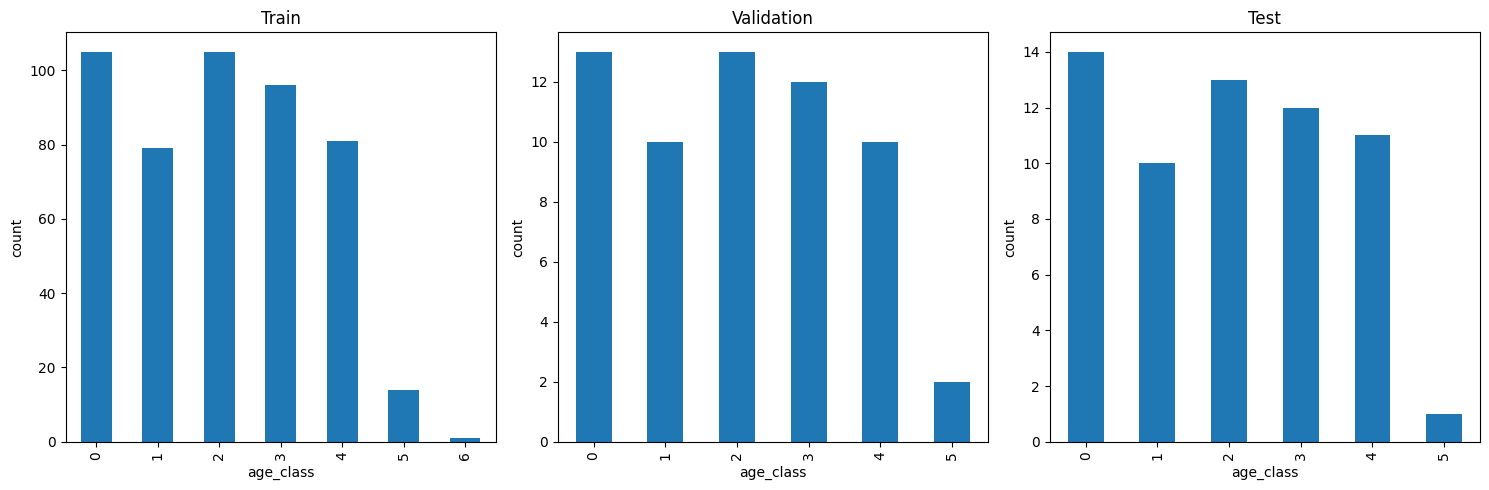

In [7]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [8]:
# train, val, test의 개수 합이 origin과 같으면 한 사람이 여러장 찍지 않았음
len(origin_df), len(train_df), len(val_df), len(test_df)

(2465, 481, 60, 61)

In [9]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])

split_train.drop(columns=['age_class_x'], inplace=True)
split_train.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_val.drop(columns=['age_class_x'], inplace=True)
split_val.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_test.drop(columns=['age_class_x'], inplace=True)
split_test.rename(columns={'age_class_y': 'age_class'}, inplace=True)

# user_id로 교집합을 구하여 중복된 user_id의 수를 확인
len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [10]:
with open(os.path.join(label_dir, 'age_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 282_data

In [50]:
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/datasets/v0.2_data/age/282_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'age_label.json'), orient='records', dtype={'user_id':str, })
user_split = origin_df.loc[:, ['user_id', 'age_class']].drop_duplicates(ignore_index=True)
user_split

,user_id,age_class
0,ID0001,1
1,ID0002,2
2,ID0003,2
3,ID0004,1
4,ID0005,3
...,...,...
1955,ID5095,1
1956,ID5103,2
1957,ID6000,2
1958,ID6001,1


In [51]:
len(user_split), len(user_split['user_id'].unique())

(1960, 1960)

In [52]:
user_split['age_class'].value_counts().sort_index()

age_class
0     37
1    723
2    714
3    195
4    179
5     86
6     26
Name: count, dtype: int64

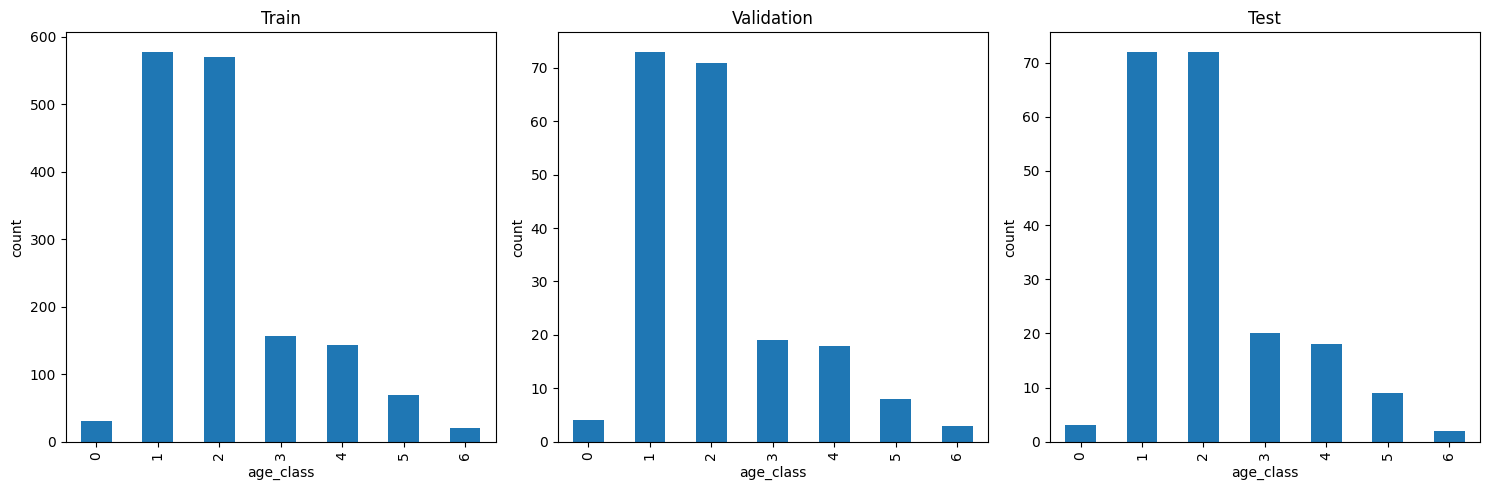

In [53]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [54]:
# train, val, test의 개수 합이 origin과 같으면 한 사람이 여러장 찍지 않았음
len(origin_df), len(train_df), len(val_df), len(test_df)

(23921, 1568, 196, 196)

In [55]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])

split_train.drop(columns=['age_class_x'], inplace=True)
split_train.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_val.drop(columns=['age_class_x'], inplace=True)
split_val.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_test.drop(columns=['age_class_x'], inplace=True)
split_test.rename(columns={'age_class_y': 'age_class'}, inplace=True)

# user_id로 교집합을 구하여 중복된 user_id의 수를 확인
len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [56]:
with open(os.path.join(label_dir, 'age_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 999_data

In [147]:
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/v0.2_data/age/999_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'age_label.json'), orient='records', dtype={'user_id':str, })
user_split = origin_df.loc[:, ['user_id', 'age_class']].drop_duplicates(ignore_index=True)
user_split

,user_id,age_class
0,31001,1
1,31002,2
2,31003,2
3,31004,2
4,31005,1
...,...,...
296,6298,4
297,6299,2
298,6300,3
299,6301,1


In [149]:
len(user_split), len(user_split['user_id'].unique())

(301, 301)

In [150]:
user_split['age_class'].value_counts().sort_index()

age_class
0      3
1    136
2    108
3     26
4     18
5      9
6      1
Name: count, dtype: int64

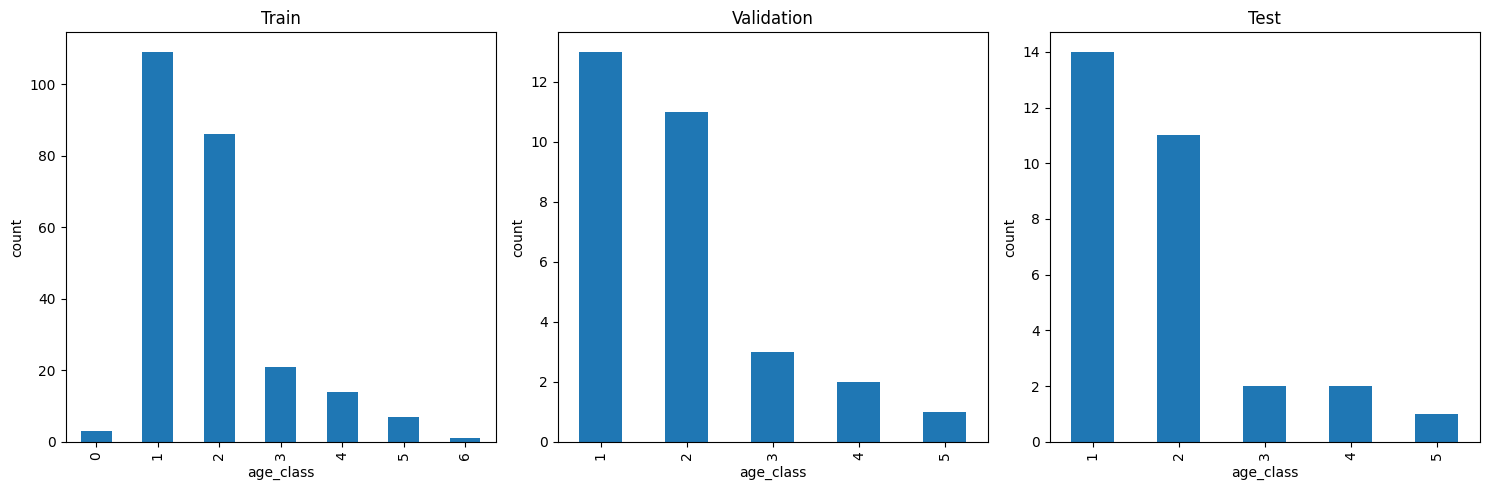

In [151]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [152]:
# train, val, test의 개수 합이 origin과 같으면 한 사람이 여러장 찍지 않았음
len(origin_df), len(train_df), len(val_df), len(test_df)

(1990, 241, 30, 30)

In [153]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])

split_train.drop(columns=['age_class_x'], inplace=True)
split_train.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_val.drop(columns=['age_class_x'], inplace=True)
split_val.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_test.drop(columns=['age_class_x'], inplace=True)
split_test.rename(columns={'age_class_y': 'age_class'}, inplace=True)

# user_id로 교집합을 구하여 중복된 user_id의 수를 확인
len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [154]:
with open(os.path.join(label_dir, 'age_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 114_data

In [2]:
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/datasets/v0.2_data/age/114_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'age_label.json'), orient='records', dtype={'user_id':str, })
user_split = origin_df.loc[:, ['user_id', 'age_class']].drop_duplicates(ignore_index=True)
user_split

,user_id,age_class
0,0166,1
1,0171,4
2,0175,1
3,0179,1
4,0183,0
...,...,...
1242,2976,0
1243,2978,3
1244,2989,2
1245,2994,0


In [3]:
# user_split에 user_id의 개수와 고유한 user_id의 개수를 확인
len(user_split), len(user_split['user_id'].unique())

(1247, 1247)

In [4]:
origin_df[origin_df['age_class'] == 0]

,user_id,path,gender,age,age_class
227,0183,114_data/data/0183_Phone_High_001.jpg,female,10s,0
228,0183,114_data/data/0183_Phone_High_002.jpg,female,10s,0
229,0183,114_data/data/0183_Phone_High_003.jpg,female,10s,0
230,0183,114_data/data/0183_Phone_High_004.jpg,female,10s,0
231,0183,114_data/data/0183_Phone_High_005.jpg,female,10s,0
...,...,...,...,...,...
59557,2995,114_data/data/2995_Tablet_Mid_021.jpg,male,10s,0
59558,2995,114_data/data/2995_Tablet_Mid_023.jpg,male,10s,0
59559,2995,114_data/data/2995_Tablet_Mid_024.jpg,male,10s,0
59560,2995,114_data/data/2995_Tablet_Mid_029.jpg,male,10s,0


In [5]:
user_split['age_class'].value_counts().sort_index()

age_class
0    116
1    373
2    307
3    238
4     81
5     94
6     38
Name: count, dtype: int64

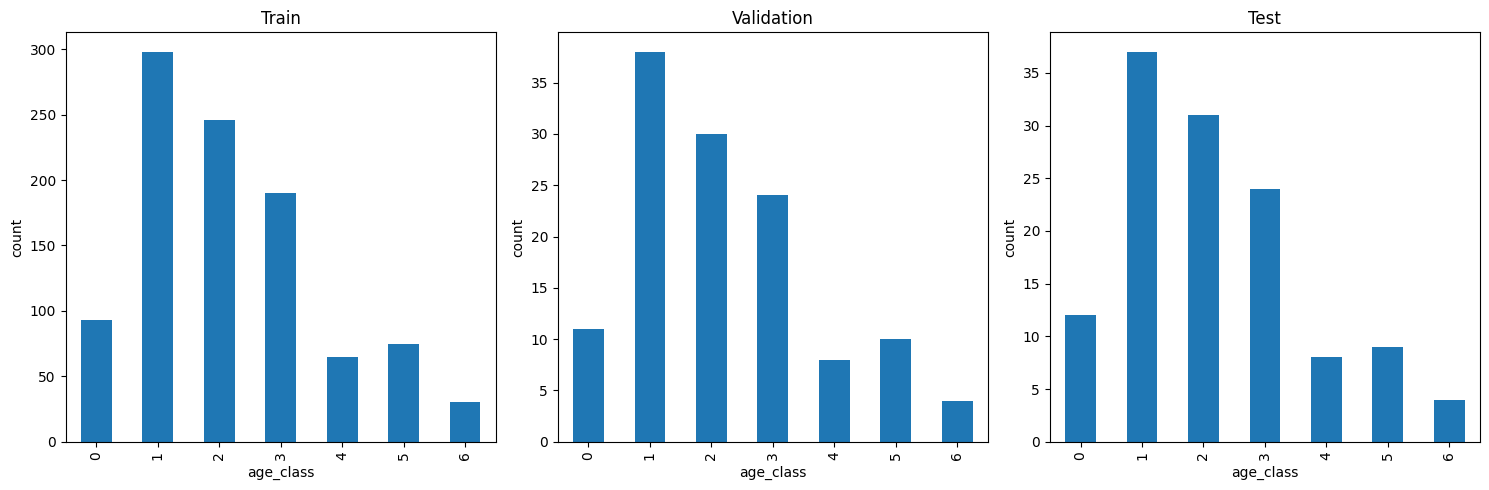

In [6]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [7]:
# train, val, test의 개수 합이 origin과 같으면 한 사람이 여러장 찍지 않았음
len(origin_df), len(train_df), len(val_df), len(test_df)

(59562, 997, 125, 125)

In [8]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'path'])

split_train.drop(columns=['age_class_x'], inplace=True)
split_train.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_val.drop(columns=['age_class_x'], inplace=True)
split_val.rename(columns={'age_class_y': 'age_class'}, inplace=True)
split_test.drop(columns=['age_class_x'], inplace=True)
split_test.rename(columns={'age_class_y': 'age_class'}, inplace=True)

# user_id로 교집합을 구하여 중복된 user_id의 수를 확인
len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [9]:
with open(os.path.join(label_dir, 'age_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'age_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)